# Merge Sort and Quicksort

## Merge Sort

Merge sort is a divide-and-conquer algorithm:

- **Divide** the array into two halves.
- **Conquer** by recursively sorting each half.
- **Combine** the two sorted halves using a `merge` step that runs in $O(n)$ time.

Overall running time: $O(n \log n)$ in all cases.

In [6]:
def merge(left, right):
    """Merge two sorted lists into a single sorted list."""
    result = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    # Append any remaining elements
    result.extend(left[i:])
    result.extend(right[j:])
    return result


def merge_sort(arr):
    """Sort a list using merge sort. Returns a new sorted list."""
    if len(arr) <= 1:
        return arr[:]

    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])

    return merge(left, right)


In [7]:
# Quick test
test_array = [38, 27, 43, 3, 9, 82, 10]
print("Original:", test_array)
print("Sorted:  ", merge_sort(test_array))


Original: [38, 27, 43, 3, 9, 82, 10]
Sorted:   [3, 9, 10, 27, 38, 43, 82]


## Randomized Quicksort

Quicksort is also divide-and-conquer, but it does the work *before* the recursive calls (via partitioning) instead of after (via merging):

- **Pick a pivot.**
- **Partition** the array so elements smaller than the pivot come before it and elements larger come after.
- **Recurse** on the two partitions.

In this implementation, `partition(A, p, q)` uses `A[p]` (the first element of the range) as the pivot `x`. `randomized_partition` picks a uniformly random element and swaps it into position `p` first, then calls the same `partition` — this is what makes the pivot choice random and avoids the $O(n^2)$ worst case that a fixed first-element pivot hits on already-sorted or adversarial input.

This implementation sorts **in place**.

In [8]:
import random

def partition(arr, p, q):
    """Partition arr[p..q] using arr[p] as the pivot.
    Rearranges arr[p..q] in place and returns the pivot's final index i,
    such that arr[p..i-1] <= arr[i] and arr[i+1..q] > arr[i]."""
    x = arr[p]      # pivot
    i = p
    for j in range(p + 1, q + 1):
        if arr[j] <= x:
            i = i + 1
            arr[i], arr[j] = arr[j], arr[i]
    arr[p], arr[i] = arr[i], arr[p]
    return i


def randomized_partition(arr, p, q):
    """Choose a random pivot, swap it into position p, then partition normally."""
    rand_index = random.randint(p, q)
    arr[rand_index], arr[p] = arr[p], arr[rand_index]
    return partition(arr, p, q)


def quicksort(arr, p=0, q=None):
    """Sort arr[p..q] in place using randomized quicksort."""
    if q is None:
        q = len(arr) - 1

    if p < q:
        pivot_index = randomized_partition(arr, p, q)
        quicksort(arr, p, pivot_index - 1)
        quicksort(arr, pivot_index + 1, q)

    return arr


In [9]:
# Quick test
test_array = [38, 27, 43, 3, 9, 82, 10]
print("Original:", test_array)
quicksort(test_array)
print("Sorted:  ", test_array)


Original: [38, 27, 43, 3, 9, 82, 10]
Sorted:   [3, 9, 10, 27, 38, 43, 82]


**Note:** unlike `merge_sort` above (which returns a *new* list), `quicksort` sorts *in place* and also returns the array for convenience. Keep this difference in mind — you may need to pass in a **copy** of a list (`arr[:]` or `list(arr)`) if you want to keep the original around.

## Plotting a graph to illustrate that Randomized Quicksort is generally faster than Mergesort


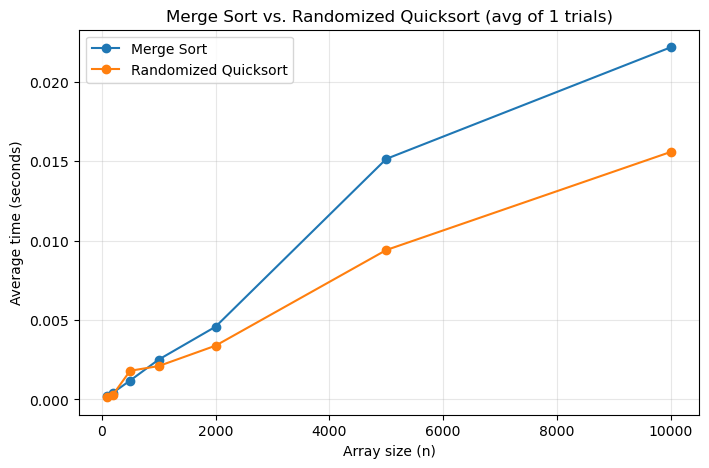

In [10]:
import time
import matplotlib.pyplot as plt

sizes = [100, 200, 500, 1000, 2000, 5000, 10000]
num_trials = 1

def avg_time(sort_fn, arrays):
    total = 0.0
    for arr in arrays:
        a = arr[:]  # always sort a fresh copy
        t0 = time.perf_counter()
        sort_fn(a)
        total += time.perf_counter() - t0
    return total / len(arrays)

merge_times = []
quick_times = []

for n in sizes:
    # Wide value range relative to n, to avoid heavy duplication skewing quicksort
    arrays = [[random.randint(0, 10**9) for _ in range(n)] for _ in range(num_trials)]

    merge_times.append(avg_time(lambda a: merge_sort(a), arrays))
    quick_times.append(avg_time(lambda a: quicksort(a), arrays))

plt.figure(figsize=(8, 5))
plt.plot(sizes, merge_times, marker='o', label='Merge Sort')
plt.plot(sizes, quick_times, marker='o', label='Randomized Quicksort')
plt.xlabel('Array size (n)')
plt.ylabel('Average time (seconds)')
plt.title(f'Merge Sort vs. Randomized Quicksort (avg of {num_trials} trials)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

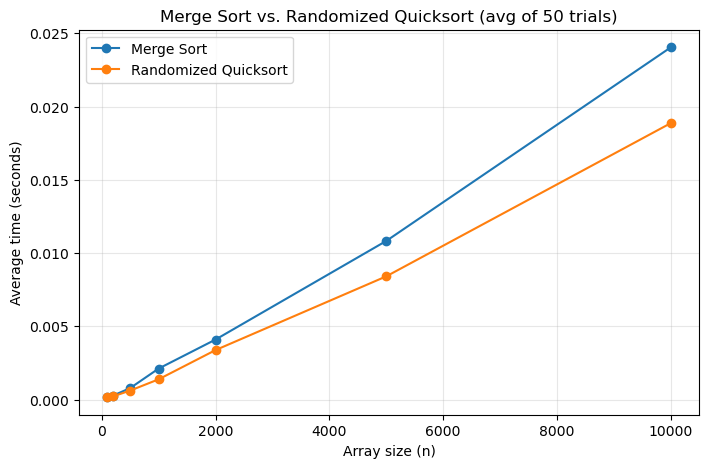

In [15]:
sizes = [100, 200, 500, 1000, 2000, 5000, 10000]
num_trials = 50

def avg_time(sort_fn, arrays):
    total = 0.0
    for arr in arrays:
        a = arr[:]  # always sort a fresh copy
        t0 = time.perf_counter()
        sort_fn(a)
        total += time.perf_counter() - t0
    return total / len(arrays)

merge_times = []
quick_times = []

for n in sizes:
    # Wide value range relative to n, to avoid heavy duplication skewing quicksort
    random.sample(range(n * 100), n)
    arrays = [random.sample(range(n * 100), n) for _ in range(num_trials)]
    #arrays = [[random.randint(0, 10**9) for _ in range(n)] for _ in range(num_trials)]

    merge_times.append(avg_time(lambda a: merge_sort(a), arrays))
    quick_times.append(avg_time(lambda a: quicksort(a), arrays))

plt.figure(figsize=(8, 5))
plt.plot(sizes, merge_times, marker='o', label='Merge Sort')
plt.plot(sizes, quick_times, marker='o', label='Randomized Quicksort')
plt.xlabel('Array size (n)')
plt.ylabel('Average time (seconds)')
plt.title(f'Merge Sort vs. Randomized Quicksort (avg of {num_trials} trials)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## EXERCISE

Refer your previous submission. 

If quicksort was not able to beat mergesort by a good margin, correct your code or input as per the above demonstration. Mention what went wrong in your previous submission.

If your previous submission was showing a good margin, then mention what went right and improve your margin using the above demonstration.

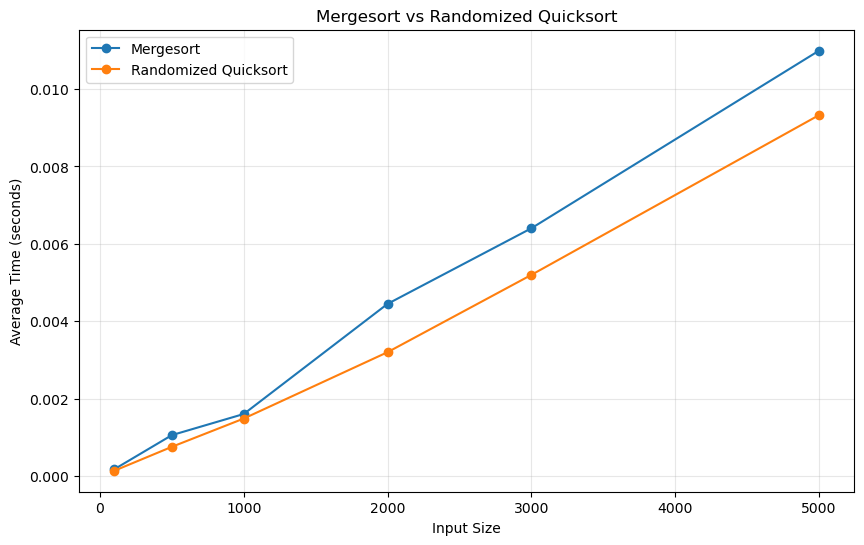

In [17]:
#Corrected code according to demonstration:

sizes2 = [100, 500, 1000, 2000, 3000, 5000]
num_trials = 50

quick_times2 = []
merge_times2 = []

def avg_time(sort_fn, arrays):
    total = 0.0

    for arr in arrays:
        data = arr.copy()

        start = time.perf_counter()
        sort_fn(data)
        total += time.perf_counter() - start

    return total / len(arrays)

for n in sizes2:
    # Generate random arrays with a wide range of values
    arrays = [
        random.sample(range(n * 100), n)
        for _ in range(num_trials)
    ]
    merge_times2.append(
        avg_time(lambda a: merge_sort(a), arrays)
    )
    quick_times2.append(
        avg_time(lambda a: quicksort(a), arrays)
    )
plt.figure(figsize=(10, 6))
plt.plot(
    sizes2,
    merge_times2,
    marker='o',
    label="Mergesort"
)
plt.plot(
    sizes2,
    quick_times2,
    marker='o',
    label="Randomized Quicksort"
)
plt.xlabel("Input Size")
plt.ylabel("Average Time (seconds)")
plt.title("Mergesort vs Randomized Quicksort")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Why quicksort didn't beat mergesort in my previous submission:

my old code shows a slower quicksort because:

1) It uses an already sorted array: list(range(n)).

2) Randomized Quicksort has extra overhead from randomly selecting pivots.

3) It runs each input size only once, so timing can be noisy.

4) The new code uses random arrays and averages 50 trials, giving Quicksort a more favorable and reliable comparison.